In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("设备:", device)

# 一个简单的全连接网络：输入(x,t)，输出该点的温度u
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 50), nn.Tanh(),   # 输入是 (x,t) 两个数
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 50), nn.Tanh(),
            nn.Linear(50, 1)               # 输出是 u（温度）
        )
    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

model = PINN().to(device)
print(model)

设备: cuda
PINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=50, bias=True)
    (1): Tanh()
    (2): Linear(in_features=50, out_features=50, bias=True)
    (3): Tanh()
    (4): Linear(in_features=50, out_features=50, bias=True)
    (5): Tanh()
    (6): Linear(in_features=50, out_features=1, bias=True)
  )
)


In [2]:
alpha = 0.1

def pde_residual(model, x, t):
    """计算物理方程的残差：∂u/∂t - α·∂²u/∂x²，理想情况应该=0"""
    u = model(x, t)

    # 自动微分求导数
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u),
                              create_graph=True)[0]          # ∂u/∂t
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u),
                              create_graph=True)[0]          # ∂u/∂x
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x),
                               create_graph=True)[0]         # ∂²u/∂x²

    residual = u_t - alpha * u_xx     # 这就是热传导方程，理想=0
    return residual

In [3]:
N_f = 2000   # 方程点：区域内部随机撒2000个点
N_b = 100    # 边界/初始点

# ① 内部点（用来满足方程）—— 随机撒在 x∈[0,1], t∈[0,1]
x_f = torch.rand(N_f, 1, device=device, requires_grad=True)
t_f = torch.rand(N_f, 1, device=device, requires_grad=True)

# ② 初始条件点 t=0：u(x,0)=sin(πx)
x_ic = torch.rand(N_b, 1, device=device)
t_ic = torch.zeros(N_b, 1, device=device)
u_ic = torch.sin(np.pi * x_ic)

# ③ 边界点 x=0 和 x=1：u=0
t_bc = torch.rand(N_b, 1, device=device)
x_bc0 = torch.zeros(N_b, 1, device=device)
x_bc1 = torch.ones(N_b, 1, device=device)

print("训练点生成完成")
print("内部点:", x_f.shape, "初始点:", x_ic.shape, "边界点:", t_bc.shape)

训练点生成完成
内部点: torch.Size([2000, 1]) 初始点: torch.Size([100, 1]) 边界点: torch.Size([100, 1])


In [4]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
mse = nn.MSELoss()

EPOCHS = 5000
for epoch in range(EPOCHS):
    optimizer.zero_grad()

    # 损失1：方程残差（内部点处应满足热传导方程）
    res = pde_residual(model, x_f, t_f)
    loss_pde = mse(res, torch.zeros_like(res))

    # 损失2：初始条件 u(x,0)=sin(πx)
    u_ic_pred = model(x_ic, t_ic)
    loss_ic = mse(u_ic_pred, u_ic)

    # 损失3：边界条件 u(0,t)=u(1,t)=0
    u_bc0 = model(x_bc0, t_bc)
    u_bc1 = model(x_bc1, t_bc)
    loss_bc = mse(u_bc0, torch.zeros_like(u_bc0)) + mse(u_bc1, torch.zeros_like(u_bc1))

    # 总损失
    loss = loss_pde + loss_ic + loss_bc
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d} | Total: {loss.item():.5f} | PDE: {loss_pde.item():.5f} | IC: {loss_ic.item():.5f} | BC: {loss_bc.item():.5f}")

print("训练完成！")

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch     0 | Total: 0.42145 | PDE: 0.00006 | IC: 0.38724 | BC: 0.03414
Epoch   500 | Total: 0.00034 | PDE: 0.00027 | IC: 0.00003 | BC: 0.00005
Epoch  1000 | Total: 0.00007 | PDE: 0.00006 | IC: 0.00000 | BC: 0.00001
Epoch  1500 | Total: 0.00040 | PDE: 0.00004 | IC: 0.00014 | BC: 0.00021
Epoch  2000 | Total: 0.00003 | PDE: 0.00002 | IC: 0.00000 | BC: 0.00000
Epoch  2500 | Total: 0.00002 | PDE: 0.00002 | IC: 0.00000 | BC: 0.00000
Epoch  3000 | Total: 0.00002 | PDE: 0.00001 | IC: 0.00000 | BC: 0.00000
Epoch  3500 | Total: 0.00001 | PDE: 0.00001 | IC: 0.00000 | BC: 0.00000
Epoch  4000 | Total: 0.00001 | PDE: 0.00001 | IC: 0.00000 | BC: 0.00000
Epoch  4500 | Total: 0.00145 | PDE: 0.00002 | IC: 0.00054 | BC: 0.00090
训练完成！


In [5]:
# 解析解（真实答案）：u(x,t) = sin(πx)·exp(-α·π²·t)
def exact_solution(x, t):
    return np.sin(np.pi * x) * np.exp(-alpha * np.pi**2 * t)

# 生成测试网格
x_test = np.linspace(0, 1, 100)
t_test = np.linspace(0, 1, 100)
X, T = np.meshgrid(x_test, t_test)

# PINN 预测
xt = np.stack([X.ravel(), T.ravel()], axis=1)
x_tensor = torch.tensor(xt[:,0:1], dtype=torch.float32, device=device)
t_tensor = torch.tensor(xt[:,1:2], dtype=torch.float32, device=device)
with torch.no_grad():
    u_pred = model(x_tensor, t_tensor).cpu().numpy().reshape(X.shape)

# 真实解
u_exact = exact_solution(X, T)

# 误差
error = np.abs(u_pred - u_exact)
print(f"最大绝对误差: {error.max():.6f}")
print(f"平均绝对误差: {error.mean():.6f}")

最大绝对误差: 0.002343
平均绝对误差: 0.000512


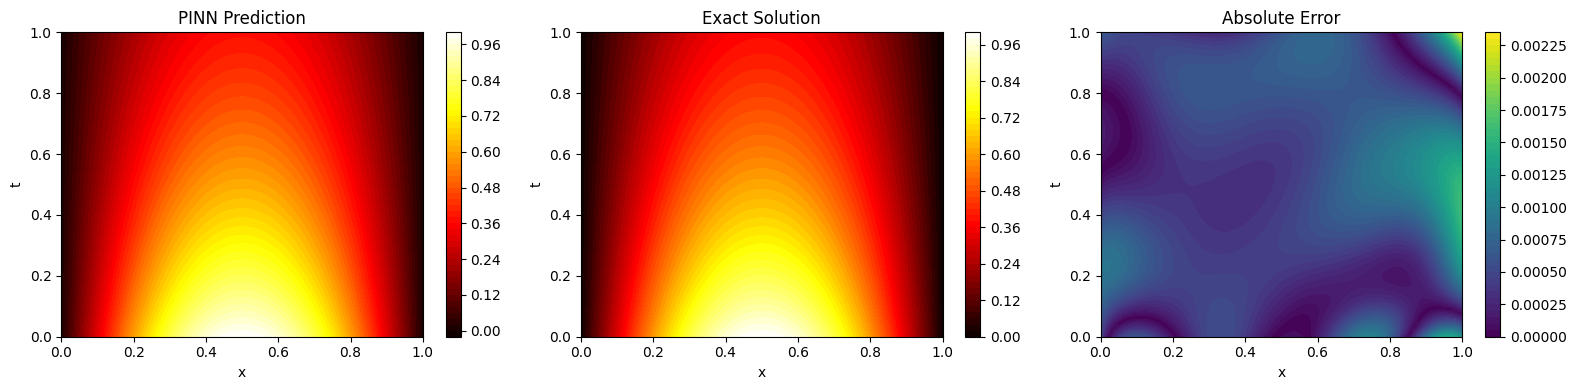

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

im0 = axes[0].contourf(X, T, u_pred, levels=50, cmap='hot')
axes[0].set_title('PINN Prediction'); axes[0].set_xlabel('x'); axes[0].set_ylabel('t')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(X, T, u_exact, levels=50, cmap='hot')
axes[1].set_title('Exact Solution'); axes[1].set_xlabel('x'); axes[1].set_ylabel('t')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].contourf(X, T, error, levels=50, cmap='viridis')
axes[2].set_title('Absolute Error'); axes[2].set_xlabel('x'); axes[2].set_ylabel('t')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.savefig('pinn_heat.png', dpi=150, bbox_inches='tight')
plt.show()